In [2]:
# Dataset download
## Kaggle API Token 업로드 코드

from google.colab import files

# 파일 업로드 대화 상자를 띄웁니다.
print("Kaggle API Token (kaggle.json) 파일을 선택하여 업로드해주세요.")
uploaded = files.upload()

# 업로드된 파일 이름을 확인합니다.
if 'kaggle.json' in uploaded:
    print("kaggle.json 파일 업로드 완료.")

    # .kaggle 디렉토리를 생성하고 kaggle.json을 이동/복사합니다.
    # Kaggle CLI가 파일을 찾을 수 있도록 표준 위치에 저장합니다.
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/

    # API 키 파일에 대한 권한을 설정합니다 (보안을 위해 필수).
    !chmod 600 ~/.kaggle/kaggle.json

    print("Kaggle 환경 설정 완료. 이제 !kaggle 명령어를 사용할 수 있습니다.")
else:
    print("'kaggle.json' 파일이 업로드되지 않았거나 파일명이 다릅니다.")
# Kaggle API 설정 및 데이터셋 다운로드



Kaggle API Token (kaggle.json) 파일을 선택하여 업로드해주세요.


Saving kaggle.json to kaggle (1).json
'kaggle.json' 파일이 업로드되지 않았거나 파일명이 다릅니다.
다운로드 실패: name 'os' is not defined
   수동으로 데이터셋을 다운로드하여 업로드해주세요.


In [3]:
# 섹션 1: 환경 설정 및 라이브러리 설치

# 필요한 라이브러리 설치 (에러 방지를 위해 패키지 이름 수정 및 설치 명령어 분리)
# grad-cam: Grad-CAM 시각화를 위한 라이브러리 (pytorch-grad-cam 대신 사용)
# pydicom: DICOM 파일을 읽기 위한 라이브러리
# opendatasets: Kaggle 데이터셋 다운로드용

!pip install -q pydicom opendatasets
!pip install -q grad-cam # pytorch-grad-cam 대신 grad-cam 설치

# 기본 라이브러리 임포트
import os  # 파일 및 디렉토리 관리
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 시각화
from PIL import Image  # 이미지 처리
import torch  # PyTorch 메인 라이브러리
import torch.nn as nn  # 신경망 모듈
import torch.optim as optim  # 최적화 알고리즘
from torch.utils.data import Dataset, DataLoader  # 데이터 로딩
import torchvision.transforms as transforms  # 이미지 변환
from torchvision import models  # 사전학습된 모델
from torchvision.models import ResNet18_Weights # 최신 가중치 로드 방식
from sklearn.metrics import confusion_matrix, classification_report  # 평가 지표
import seaborn as sns  # 시각화 (confusion matrix용)
import pydicom  # DICOM 파일 읽기
# Grad-CAM 관련 라이브러리 임포트 (모듈명은 pytorch_grad_cam을 유지)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 랜덤 시드 고정 (재현 가능한 결과를 위해)
SEED = 42
torch.manual_seed(SEED)  # PyTorch 시드
np.random.seed(SEED)  # NumPy 시드
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True # 결정적 알고리즘 사용
    torch.backends.cudnn.benchmark = False   # 속도보다는 재현성 우선

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")
print(f"PyTorch 버전: {torch.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
사용 디바이스: cuda
PyTorch 버전: 2.10.0+cu128


In [4]:
try:
    # files.upload() 대신 파일이 업로드되었다고 가정하고 셸 명령 실행
    # (Colab 환경에서 블록킹 오류를 방지하기 위함)
    if os.path.exists("kaggle.json"):
        from google.colab import files # files 모듈 임포트 유지

        # Kaggle 디렉토리 생성 및 파일 이동
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json

        # 데이터셋 다운로드
        !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p ./data

        # 압축 해제
        !unzip -o -q ./data/chest-xray-pneumonia.zip -d ./data/

        # 불필요한 파일/폴더 제거
        !rm ./data/chest-xray-pneumonia.zip
        !rm -rf ./data/__MACOSX

        print("다운로드 완료!")
        data_dir = "./data/chest_xray"
    else:
        print("'kaggle.json' 파일을 찾을 수 없습니다. 파일을 업로드해주세요.")
        data_dir = "./data/chest_xray" # 경로 변수는 설정

except Exception as e:
    print(f"다운로드 실패: {e}")
    print("   수동으로 데이터셋을 다운로드하여 업로드해주세요.")
    data_dir = "./data/chest_xray" # 실패하더라도 경로 변수는 설정


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.26G/2.29G [00:20<00:00, 153MB/s]
100% 2.29G/2.29G [00:20<00:00, 119MB/s]
다운로드 완료!


In [7]:
#check data structure
if os.path.exists(data_dir):
    check_dir = os.path.join(data_dir, "train")
    if os.path.exists(check_dir):
        for split in ['train', 'test']:
            print(f"  {split.upper()}/")
            for class_name in ['NORMAL', 'PNEUMONIA']:
                class_path = os.path.join(data_dir, split, class_name)
                if os.path.exists(class_path):
                    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
                    print(f"    {class_name}/")
                    for file in files[:3]:
                         print(f"      {file}")
                    if len(files) > 3:
                        print(f"      ... (in total {len(files)} files)")

  TRAIN/
    NORMAL/
      NORMAL2-IM-1096-0001.jpeg
      NORMAL2-IM-0954-0001.jpeg
      NORMAL2-IM-0490-0001.jpeg
      ... (in total 1341 files)
    PNEUMONIA/
      person464_virus_956.jpeg
      person808_virus_1442.jpeg
      person409_virus_820.jpeg
      ... (in total 3875 files)
  TEST/
    NORMAL/
      NORMAL2-IM-0335-0001.jpeg
      NORMAL2-IM-0173-0001-0001.jpeg
      IM-0061-0001.jpeg
      ... (in total 234 files)
    PNEUMONIA/
      person1613_virus_2799.jpeg
      person119_bacteria_567.jpeg
      person114_bacteria_545.jpeg
      ... (in total 390 files)



데이터셋 통계:
   Train - NORMAL: 1341장
   Train - PNEUMONIA: 3875장
   Test - NORMAL: 234장
   Test - PNEUMONIA: 390장

 check sample image


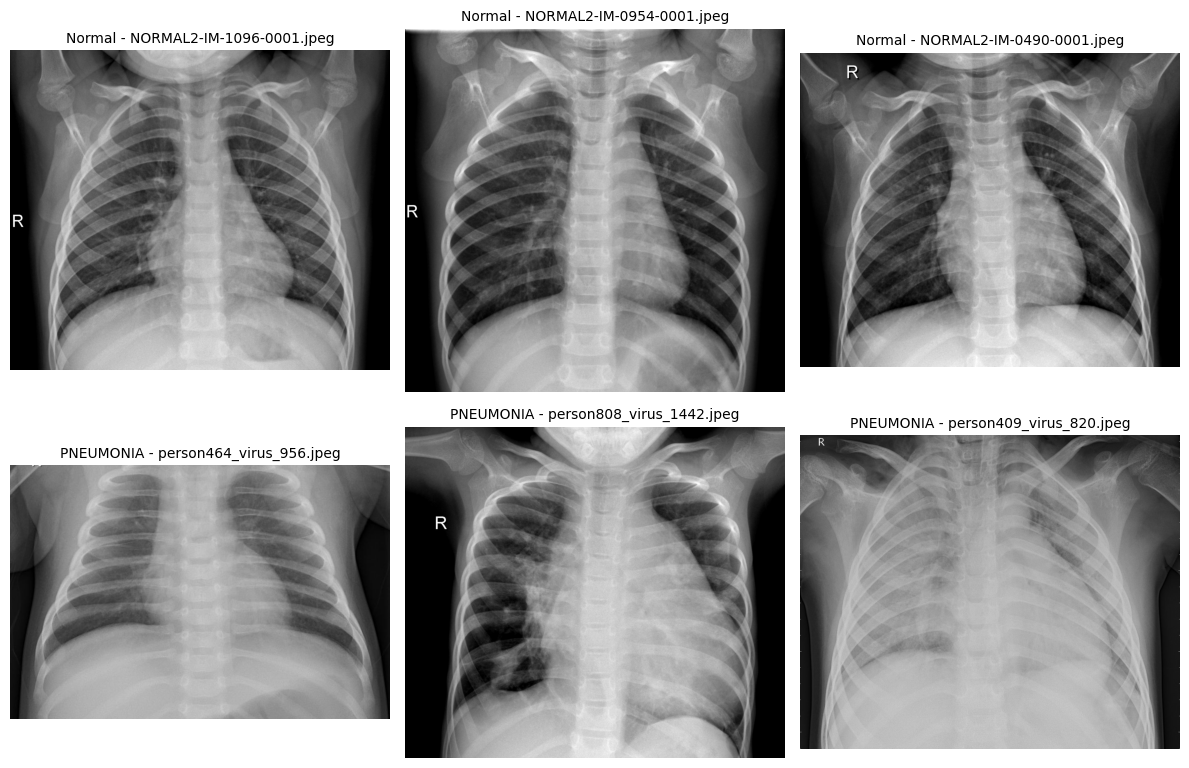

In [10]:
# analysis dataset
if os.path.exists(os.path.join(data_dir, 'train/NORMAL')):
  train_normal = len(os.listdir(os.path.join(data_dir,"train/NORMAL")))
  train_pneumonia = len(os.listdir(os.path.join(data_dir,"train/PNEUMONIA")))
  test_normal = len(os.listdir(os.path.join(data_dir, "test/NORMAL")))
  test_pneumonia = len(os.listdir(os.path.join(data_dir, "test/PNEUMONIA")))

  print("\n데이터셋 통계:")
  print(f"   Train - NORMAL: {train_normal}장")
  print(f"   Train - PNEUMONIA: {train_pneumonia}장")
  print(f"   Test - NORMAL: {test_normal}장")
  print(f"   Test - PNEUMONIA: {test_pneumonia}장")

  if train_normal > 0 and train_pneumonia > 0:
    print("\n check sample image")
    fig,axes = plt.subplots(2,3,figsize=(12,8))

    normal_path = os.path.join(data_dir,"train/NORMAL")
    normal_images = [f for f in os.listdir(normal_path) if f.lower().endswith(('.jpeg','jpg','png'))][:3]
    for i, img_name in enumerate(normal_images):
      img = Image.open(os.path.join(normal_path, img_name))
      axes[0,i].imshow(img,cmap='gray')
      axes[0,i].set_title(f"Normal - {img_name}", fontsize=10)
      axes[0,i].axis('off')

    # Pneumonia sample 3
    pneumonia_path = os.path.join(data_dir, "train/PNEUMONIA")
    pneumonia_images = [f for f in os.listdir(pneumonia_path) if f.lower().endswith(('.jpeg','.jpg','png'))][:3]
    for i, img_name in enumerate(pneumonia_images):
      img = Image.open(os.path.join(pneumonia_path,img_name))
      axes[1,i].imshow(img,cmap="gray")
      axes[1,i].set_title(f"PNEUMONIA - {img_name}", fontsize=10)
      axes[1,i].axis('off')
    plt.tight_layout()
    plt.savefig('sample_xray_images.png', dpi=150, bbox_inches ='tight')
    plt.show()


In [14]:
# preprocessing

IMAGENET_MEAN = [0.485,0.456,0.406]
IMAGENET_STD = [0.229,0.224,0.225]


train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),

    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class ChestXrayDataset(Dataset):
  def __init__(self,root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.images =[]
    self.labels =[]

    classes = ['NORMAL','PNEUMONIA']
    for label, class_name in enumerate(classes):
      class_dir = os.path.join(root_dir,class_name)
      if os.path.exists(class_dir):
        for img_name in os.listdir(class_dir):
          if img_name.lower().endswith(('.jpeg', '.jpg', '.png')) :
            self.images.append(os.path.join(class_dir,img_name))
            self.labels.append(label)
          else:
            pass

  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    img_path = self.images[idx]
    image = Image.open(img_path).convert('RGB')
    label = self.labels[idx]

    if self.transform :
      image= self.transform(image)
    return image, label



train_dataset = ChestXrayDataset(
    root_dir = os.path.join(data_dir,"train"),
    transform = train_transform
)

test_dataset = ChestXrayDataset(
    root_dir = os.path.join(data_dir,"test"),
    transform = test_transform
)

if len(train_dataset) == 0:
  print("tarinset is empty")

batch_size = 32
num_workers = 2

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle=False,
    num_workers=num_workers
)

print(f"   Train 데이터: {len(train_dataset)}장")
print(f"   Test 데이터: {len(test_dataset)}장")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}개")
print(f"   Test batches: {len(test_loader)}개")

   Train 데이터: 5216장
   Test 데이터: 624장
   Batch size: 32
   Train batches: 163개
   Test batches: 20개


In [15]:
# Define Model(Transfer Learning)

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# only change the last layer 1000 -> 2(normal or pneumonia)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]



학습 설정:
   - 손실 함수: CrossEntropyLoss
   - 옵티마이저: Adam
   - 학습률: 0.0001
   - 에폭 수: 5

학습 시작!

   Epoch [1/5], Batch [100/163], Loss: 0.0084

Epoch [1/5] 완료:
   평균 Loss: 0.0222
   정확도: 99.10%

   Epoch [2/5], Batch [100/163], Loss: 0.0674

Epoch [2/5] 완료:
   평균 Loss: 0.0241
   정확도: 99.04%

   Epoch [3/5], Batch [100/163], Loss: 0.0010

Epoch [3/5] 완료:
   평균 Loss: 0.0198
   정확도: 99.29%

   Epoch [4/5], Batch [100/163], Loss: 0.0319

Epoch [4/5] 완료:
   평균 Loss: 0.0205
   정확도: 99.35%

   Epoch [5/5], Batch [100/163], Loss: 0.0007

Epoch [5/5] 완료:
   평균 Loss: 0.0191
   정확도: 99.18%


학습 완료!


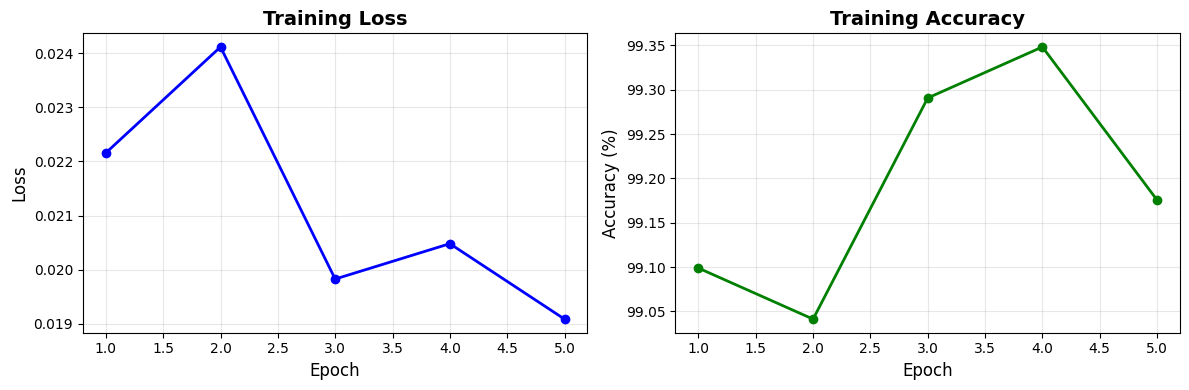

학습 곡선이 저장되었습니다: training_curves.png


In [19]:
# 모델 학습

# 손실함수
criterion = nn.CrossEntropyLoss() # 다중 클래스 분류용 손실함수
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("\n학습 설정:")
print(f"   - 손실 함수: CrossEntropyLoss")
print(f"   - 옵티마이저: Adam")
print(f"   - 학습률: 0.0001")
print(f"   - 에폭 수: 5")

# 학습 함수
def train_model(model, train_loader, criterion, optimizer, num_epochs=5):
    """
    모델 학습 함수
    Args:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        num_epochs: 학습 에폭 수
    Returns:
        train_losses: 에폭별 학습 손실
        train_accuracies: 에폭별 학습 정확도
    """
    train_losses = []  # 에폭별 손실 저장
    train_accuracies = []  # 에폭별 정확도 저장

    for epoch in range(num_epochs):
        model.train()  # 학습 모드
        running_loss = 0.0  # 현재 에폭 손실 누적
        correct = 0  # 정답 개수
        total = 0  # 전체 샘플 개수

        # 배치별 학습
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)  # 이미지를 GPU로
            labels = labels.to(device)  # 라벨을 GPU로

            # Forward pass (순전파)
            outputs = model(images)  # 모델 예측
            loss = criterion(outputs, labels)  # 손실 계산

            # Backward pass (역전파)
            optimizer.zero_grad()  # 기울기 초기화
            loss.backward()  # 역전파
            optimizer.step()  # 가중치 업데이트

            # 통계 계산
            running_loss += loss.item()  # 손실 누적
            _, predicted = torch.max(outputs.data, 1)  # 예측 클래스
            total += labels.size(0)  # 전체 샘플 수
            correct += (predicted == labels).sum().item()  # 정답 개수

            # 100 배치마다 진행상황 출력 (데이터셋 크기 고려)
            if (batch_idx + 1) % 100 == 0:
                print(f"   Epoch [{epoch+1}/{num_epochs}], "
                      f"Batch [{batch_idx+1}/{len(train_loader)}], "
                      f"Loss: {loss.item():.4f}")

        # 에폭 통계
        epoch_loss = running_loss / len(train_loader)  # 평균 손실
        epoch_acc = 100 * correct / total  # 정확도
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"\nEpoch [{epoch+1}/{num_epochs}] 완료:")
        print(f"   평균 Loss: {epoch_loss:.4f}")
        print(f"   정확도: {epoch_acc:.2f}%\n")

    return train_losses, train_accuracies

# 모델 학습 실행 (데이터가 있을 경우에만)
if len(train_dataset) > 0:
    print("\n학습 시작!\n")
    num_epochs = 5  # 초급 실습이므로 5 에폭
    train_losses, train_accuracies = train_model(
        model, train_loader, criterion, optimizer, num_epochs
    )
    print("\n학습 완료!")

    # 학습 곡선 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss 그래프
    axes[0].plot(range(1, num_epochs+1), train_losses, 'b-o', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Accuracy 그래프
    axes[1].plot(range(1, num_epochs+1), train_accuracies, 'g-o', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("학습 곡선이 저장되었습니다: training_curves.png")
else:
    print("\n학습 데이터셋이 비어있어 학습을 건너뜁니다.")
    train_losses = []
    train_accuracies = []

[[ 83 151]
 [  0 390]]


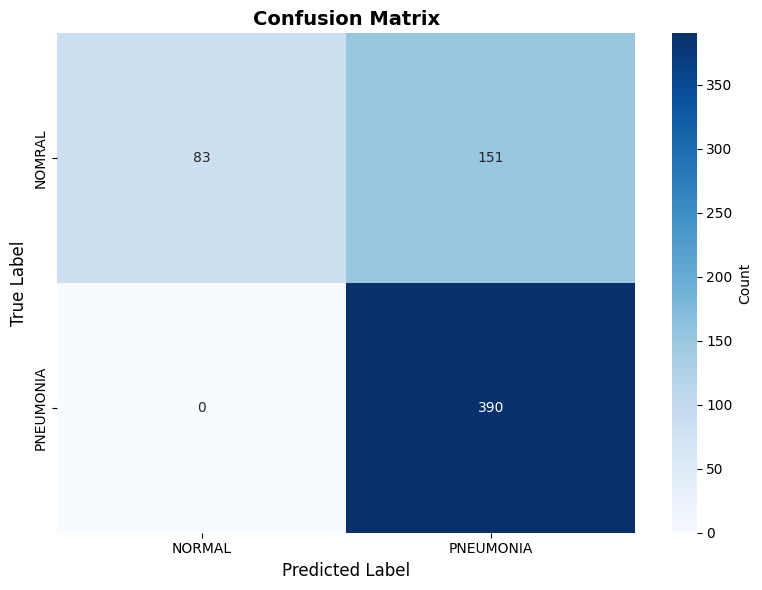

              precision    recall  f1-score   support

      NORMAL       1.00      0.35      0.52       234
   PNEUMONIA       0.72      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.68      0.68       624
weighted avg       0.83      0.76      0.72       624



In [23]:
# evaluate

def evaluate_model(model,test_loader):
  model.eval()
  correct = 0
  total = 0
  all_labels = []
  all_preds = []


  with torch.no_grad():
    for imgs, lbs in test_loader:
      imgs= imgs.to(device)
      lbs = lbs.to(device)
      outputs = model(imgs)
      _,preds = torch.max(outputs.data,1)
      total += lbs.size(0)
      correct += (preds == lbs).sum().item()
      all_labels.extend(lbs.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())

  accuracy = 100 * correct / total
  return accuracy, all_labels, all_preds

test_acc =0.0
true_lbs = []
pred_lbs =[]


if len(test_dataset) > 0 and len(train_dataset) > 0 :
  test_accuracy, true_lbs, pred_lbs = evaluate_model(model, test_loader)
  cm = confusion_matrix(true_lbs, pred_lbs)
  print(cm)

  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues',
              xticklabels =['NORMAL','PNEUMONIA'],
              yticklabels =['NOMRAL','PNEUMONIA'],
              cbar_kws={'label' : 'Count'})
  plt.xlabel('Predicted Label', fontsize=12)
  plt.ylabel('True Label', fontsize=12)
  plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
  plt.show()
  class_names= ['NORMAL','PNEUMONIA']
  print(classification_report(true_lbs, pred_lbs, target_names=class_names, zero_division =0))
else :
  print("fail")




Grad-CAM이란?
   - Gradient-weighted Class Activation Mapping
   - 모델이 어느 부분을 보고 판단했는지 시각화
   - 의료 AI의 신뢰성 향상에 필수

샘플 이미지 선택 중...


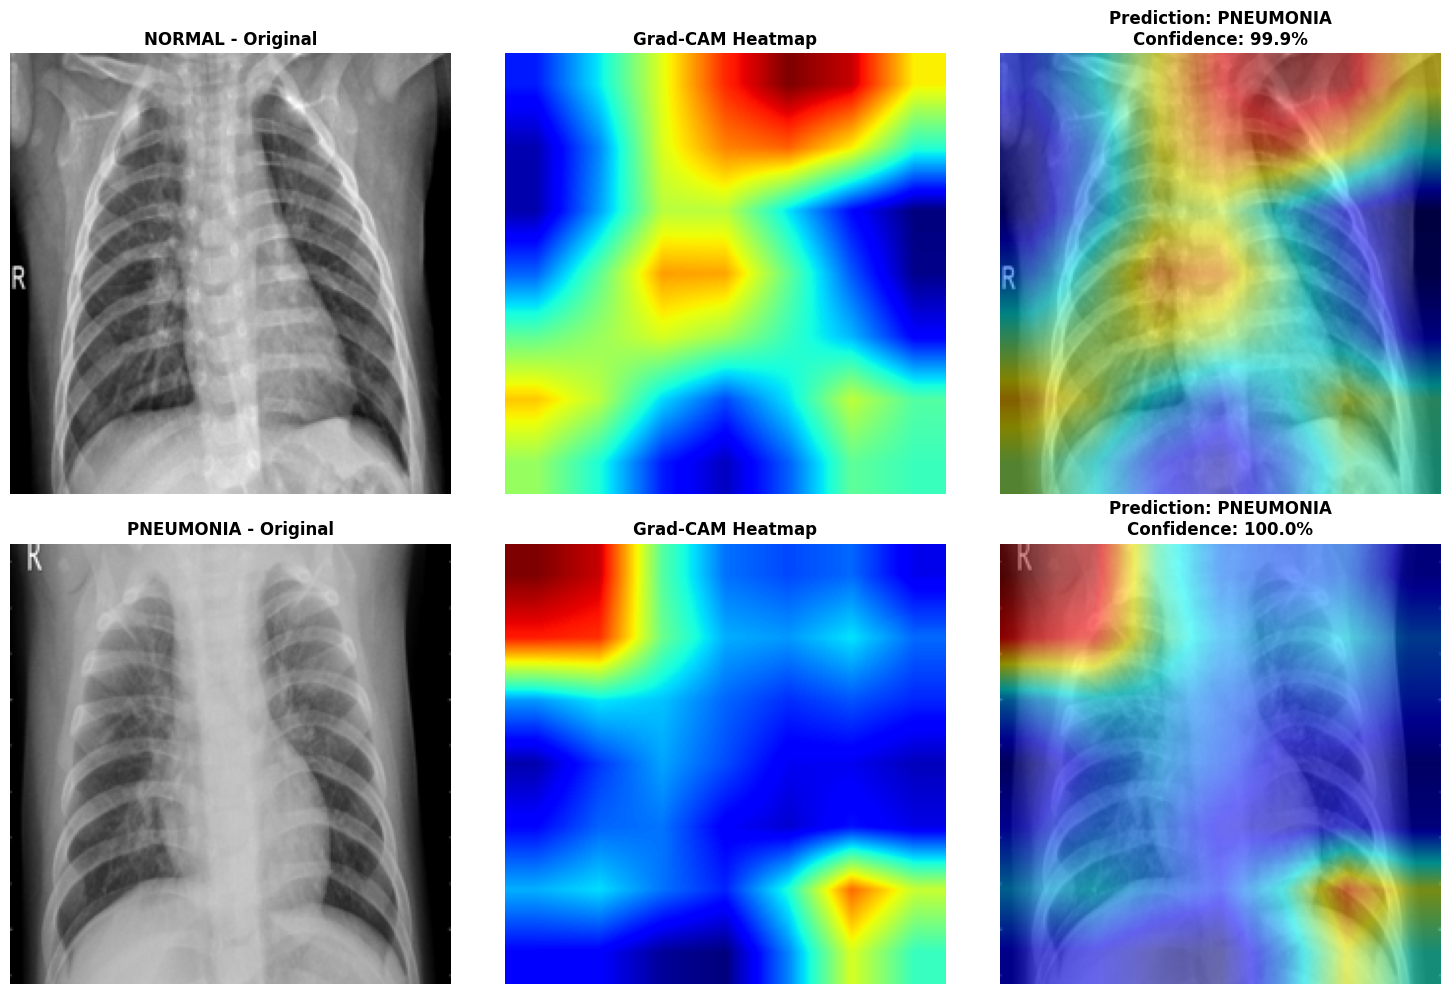

Grad-CAM 결과 저장: gradcam_results.png


In [30]:
# 섹션 8: Grad-CAM 시각화 (XAI)


if len(test_dataset) > 0 and len(train_dataset) > 0:

    print("\nGrad-CAM이란?")
    print("   - Gradient-weighted Class Activation Mapping")
    print("   - 모델이 어느 부분을 보고 판단했는지 시각화")
    print("   - 의료 AI의 신뢰성 향상에 필수")

    # Grad-CAM 설정
    target_layers = [model.layer4[-1]]  # ResNet18의 마지막 conv layer
    grad_cam = GradCAM(model=model, target_layers=target_layers) # grad_cam 변수명으로 변경 (기존 cam과 충돌 방지)

    # 테스트 이미지 선택 (각 클래스별 1장씩)
    def get_sample_images(test_dataset, num_samples=1):
        """각 클래스에서 샘플 이미지 추출"""
        samples = {'NORMAL': [], 'PNEUMONIA': []}

        for idx in range(len(test_dataset)):
            img_tensor, label = test_dataset[idx]
            class_name = 'NORMAL' if label == 0 else 'PNEUMONIA'

            if len(samples[class_name]) < num_samples:
                # 원본 이미지도 함께 저장 (경로를 통해 로드)
                # TestDataset은 경로를 반환하지 않지만, 임시로 로드한 후 원본 경로를 찾을 수 없으므로
                # 여기서는 Dataset 클래스에서 직접 경로를 가져와야 함 (단, test_dataset은 경로를 저장하지 않음)
                # 이를 위해 임시로 test_dataset을 ChestXrayDatasetAdvanced처럼 return_path=True로 구현하는 것이 이상적이나,
                # 초급 실습의 단순성을 위해, 여기서는 경로를 직접 로드할 수 있도록 test_dataset의 내부 images 리스트를 사용합니다.

                # 주의: test_dataset이 random_split으로 생성된 경우 이 방식은 작동하지 않으나,
                # 초급 코드는 random_split을 사용하지 않으므로, images 리스트를 사용합니다.

                # 안전한 방법: Dataset 클래스 내부에 경로를 저장했는지 확인하고 사용
                if hasattr(test_dataset, 'images'):
                    img_path = test_dataset.images[idx]
                    orig_img = Image.open(img_path).convert('RGB')
                    samples[class_name].append((img_tensor, label, orig_img))

            if all(len(v) >= num_samples for v in samples.values()):
                break

        return samples

    # 샘플 이미지 가져오기
    print("\n샘플 이미지 선택 중...")
    sample_images = get_sample_images(test_dataset, num_samples=1)

    # Grad-CAM 적용 및 시각화
    # 샘플이 최소한 1개라도 있어야 시각화 진행
    if sample_images['NORMAL'] and sample_images['PNEUMONIA']:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        for row, (class_name, samples) in enumerate(sample_images.items()):
            # 각 클래스에서 첫 번째 샘플을 사용
            img_tensor, label, orig_img = samples[0]

            # 모델 예측
            model.eval()
            input_tensor = img_tensor.unsqueeze(0).to(device)  # 배치 차원 추가

            with torch.no_grad():
                output = model(input_tensor)
                pred_prob = torch.softmax(output, dim=1) # (batch_size, class)
                # (1, 10) >> 이미지 1장, 클래스 10개
                pred_class = torch.argmax(pred_prob, dim=1).item()
                confidence = pred_prob[0][pred_class].item() * 100
                # pred_prob[0] : 확률리스트 [0.1, 0.8, 0.05,...]
                # [pred_class] : 예측 클래스의 index 1

            # Grad-CAM 생성
            targets = [ClassifierOutputTarget(pred_class)]
            grayscale_cam = grad_cam(input_tensor=input_tensor, targets=targets)
            # grad_cam 계산 (1,224,224) (b,h,w) 크기의 히트맵 (0-1 범위)
            grayscale_cam = grayscale_cam[0, :]
            # 0 : batch_size >> 1개, ":" 나머지 차원 (242,224) 그대로 가져와 (224,224) (h,w)


            # 원본 이미지를 numpy 배열로 변환
            orig_img_resized = orig_img.resize((224, 224))
            rgb_img = np.array(orig_img_resized, dtype=np.float32) / 255.0
            # 0-255 범위 >> 0~1 범위로 정규화(실수 변환 후)

            # CAM 오버레이
            cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

            # 시각화
            # 1. 원본 이미지
            axes[row, 0].imshow(orig_img_resized)
            axes[row, 0].set_title(f'{class_name} - Original', fontsize=12, fontweight='bold')
            axes[row, 0].axis('off')

            # 2. Grad-CAM Heatmap
            axes[row, 1].imshow(grayscale_cam, cmap='jet')
            axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
            axes[row, 1].axis('off')

            # 3. 오버레이
            axes[row, 2].imshow(cam_image)
            pred_name = 'NORMAL' if pred_class == 0 else 'PNEUMONIA'
            axes[row, 2].set_title(f'Prediction: {pred_name}\nConfidence: {confidence:.1f}%',
                                  fontsize=12, fontweight='bold')
            axes[row, 2].axis('off')

        plt.tight_layout()
        plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Grad-CAM 결과 저장: gradcam_results.png")
    else:
        print("\nGrad-CAM 시각화를 위한 NORMAL/PNEUMONIA 샘플이 부족합니다.")

else:
    print("\n학습이 진행되지 않았거나 테스트 데이터셋이 비어있어 Grad-CAM을 건너뜁니다.")

